In [3]:
import pandas as pd

chunk = pd.read_csv(r"C:\Users\lohit\Downloads\Internships\SyntexHub\Week-3\Ecommerce_Funnel_Analysis\data\2019-Nov.csv", nrows=500000)

chunk.to_csv("ecommerce_sample.csv", index=False)

print("Sample dataset created successfully!")
print(chunk.shape)

Sample dataset created successfully!
(500000, 9)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv("ecommerce_sample.csv")

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [6]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2
5,2019-11-01 00:00:01 UTC,view,1306894,2053013558920217191,computers.notebook,hp,360.09,520772685,816a59f3-f5ae-4ccd-9b23-82aa8c23d33c
6,2019-11-01 00:00:01 UTC,view,1306421,2053013558920217191,computers.notebook,hp,514.56,514028527,df8184cc-3694-4549-8c8c-6b5171877376
7,2019-11-01 00:00:02 UTC,view,15900065,2053013558190408249,NaN,rondell,30.86,518574284,5e6ef132-4d7c-4730-8c7f-85aa4082588f
8,2019-11-01 00:00:02 UTC,view,12708937,2053013553559896355,NaN,michelin,72.72,532364121,0a899268-31eb-46de-898d-09b2da950b24
9,2019-11-01 00:00:02 UTC,view,1004258,2053013555631882655,electronics.smartphone,apple,732.07,532647354,d2d3d2c6-631d-489e-9fb5-06f340b85be0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     500000 non-null  object 
 1   event_type     500000 non-null  object 
 2   product_id     500000 non-null  int64  
 3   category_id    500000 non-null  int64  
 4   category_code  337628 non-null  object 
 5   brand          425209 non-null  object 
 6   price          500000 non-null  float64
 7   user_id        500000 non-null  int64  
 8   user_session   500000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 34.3+ MB


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 500000
Columns: 9


In [9]:
df.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code    162372
brand             74791
price                 0
user_id               0
user_session          0
dtype: int64

In [10]:
df.duplicated().sum()

235

In [11]:
df.describe()

,product_id,category_id,price,user_id
count,5.000000e+05,5.000000e+05,500000.000000,5.000000e+05
mean,1.064690e+07,2.057498e+18,289.510458,5.351769e+08
std,1.191713e+07,1.883587e+16,348.069570,2.011139e+07
min,1.000978e+06,2.053014e+18,0.000000,2.749691e+08
25%,1.005197e+06,2.053014e+18,67.915000,5.159156e+08
50%,5.100526e+06,2.053014e+18,167.290000,5.308116e+08
75%,1.570012e+07,2.053014e+18,360.320000,5.542951e+08
max,6.050001e+07,2.180737e+18,2574.070000,5.663943e+08


In [12]:
#Convert Date Column
df["event_time"] = pd.to_datetime(df["event_time"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     500000 non-null  datetime64[ns, UTC]
 1   event_type     500000 non-null  object             
 2   product_id     500000 non-null  int64              
 3   category_id    500000 non-null  int64              
 4   category_code  337628 non-null  object             
 5   brand          425209 non-null  object             
 6   price          500000 non-null  float64            
 7   user_id        500000 non-null  int64              
 8   user_session   500000 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 34.3+ MB


In [13]:
#Remove duplicates
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 235
Duplicates after: 0


In [14]:
#Handling missing values
df["brand"] = df["brand"].fillna("Unknown")
df["category_code"] = df["category_code"].fillna("Unknown")

In [15]:
df.isnull().sum()

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64

In [16]:
#Save the cleaned dataset
df.to_csv("ecommerce_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [17]:
#Total events
print("Total Events:", len(df))

Total Events: 499765


In [18]:
#Event Distribution
df["event_type"].value_counts()

event_type
view        482617
purchase      9595
cart          7553
Name: count, dtype: int64

In [26]:
#Event Percentage
event_percent = (
    df["event_type"]
    .value_counts(normalize=True) * 100
).round(2)

print(event_percent)

event_type
view        96.57
purchase     1.92
cart         1.51
Name: proportion, dtype: float64


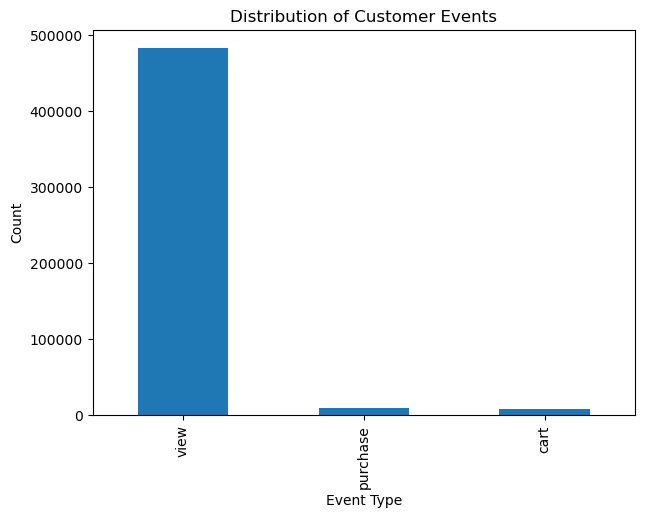

In [20]:
#Visualize EVent Distribution
import matplotlib.pyplot as plt

event_counts = df["event_type"].value_counts()

plt.figure(figsize=(7,5))
event_counts.plot(kind="bar")

plt.title("Distribution of Customer Events")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

In [22]:
#Top 10 brands
top_brands = df["brand"].value_counts().head(10)

print(top_brands)

brand
Unknown     74784
samsung     61968
apple       49579
xiaomi      36154
huawei      11743
lucente      7632
oppo         6613
cordiant     6451
lg           6189
bosch        5800
Name: count, dtype: int64


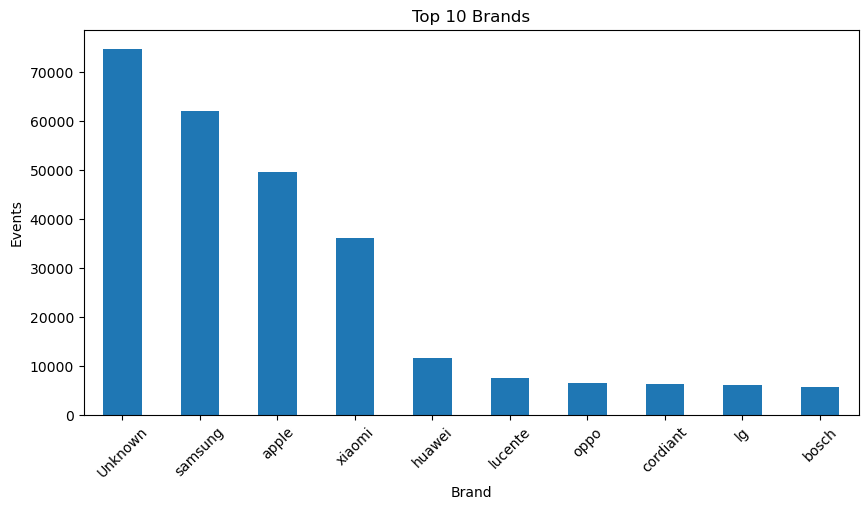

In [23]:
#Brand Chart
plt.figure(figsize=(10,5))

top_brands.plot(kind="bar")

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Events")

plt.xticks(rotation=45)

plt.show()

In [24]:
#Top Categories
top_categories = (
    df["category_code"]
    .value_counts()
    .head(10)
)

print(top_categories)

category_code
Unknown                             162337
electronics.smartphone              133542
electronics.clocks                   14237
electronics.audio.headphone          13961
electronics.video.tv                 13704
computers.notebook                   13500
appliances.kitchen.washer             9986
appliances.environment.vacuum         9877
apparel.shoes                         9476
appliances.kitchen.refrigerators      9445
Name: count, dtype: int64


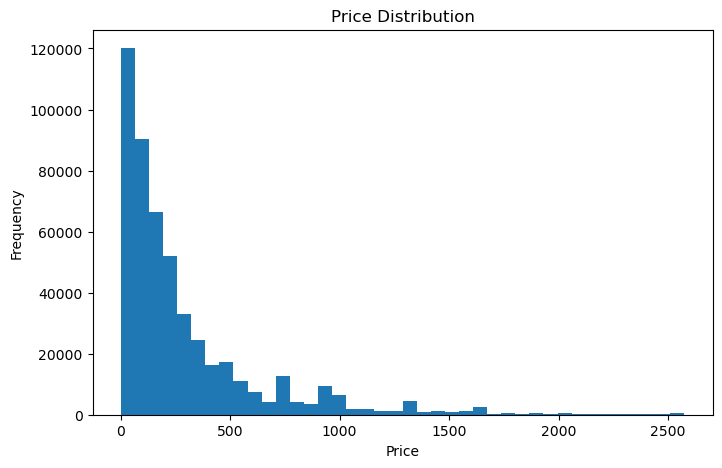

In [25]:
#Price Distribution
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=40)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [27]:
#Count EVents
views = (df["event_type"] == "view").sum()
carts = (df["event_type"] == "cart").sum()
purchases = (df["event_type"] == "purchase").sum()

print("Views:", views)
print("Cart:", carts)
print("Purchases:", purchases)

Views: 482617
Cart: 7553
Purchases: 9595


In [28]:
#Conversion Rates
view_to_cart = (carts / views) * 100
cart_to_purchase = (purchases / carts) * 100
view_to_purchase = (purchases / views) * 100

print(f"View → Cart Conversion: {view_to_cart:.2f}%")
print(f"Cart → Purchase Conversion: {cart_to_purchase:.2f}%")
print(f"Overall View → Purchase Conversion: {view_to_purchase:.2f}%")

View → Cart Conversion: 1.57%
Cart → Purchase Conversion: 127.04%
Overall View → Purchase Conversion: 1.99%


In [29]:
#Drop-off rates
view_drop = 100 - view_to_cart
cart_drop = 100 - cart_to_purchase

print(f"Drop-off after View: {view_drop:.2f}%")
print(f"Drop-off after Cart: {cart_drop:.2f}%")

Drop-off after View: 98.43%
Drop-off after Cart: -27.04%


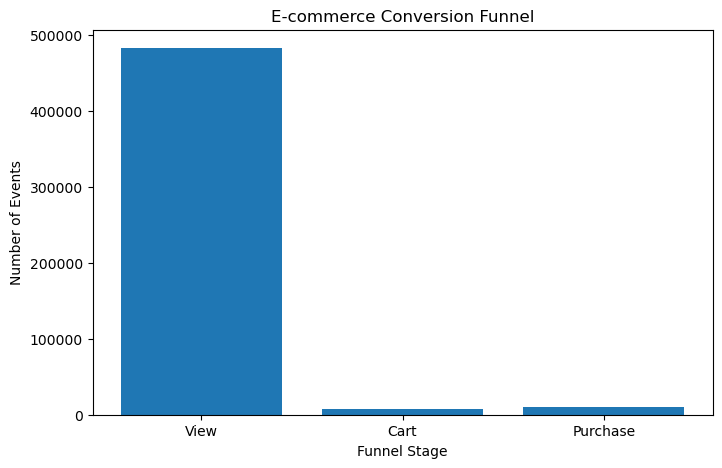

In [30]:
#Funnel Chart
import matplotlib.pyplot as plt

stages = ["View", "Cart", "Purchase"]
counts = [views, carts, purchases]

plt.figure(figsize=(8, 5))
plt.bar(stages, counts)

plt.title("E-commerce Conversion Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Events")

plt.show()

In [31]:
#Correct Version

In [32]:
view_users = df[df["event_type"] == "view"]["user_id"].nunique()

cart_users = df[df["event_type"] == "cart"]["user_id"].nunique()

purchase_users = df[df["event_type"] == "purchase"]["user_id"].nunique()

print("Unique View Users:", view_users)
print("Unique Cart Users:", cart_users)
print("Unique Purchase Users:", purchase_users)

Unique View Users: 92743
Unique Cart Users: 4501
Unique Purchase Users: 7389


In [33]:
#Correct Version

In [34]:
view_to_cart = (cart_users / view_users) * 100

cart_to_purchase = (purchase_users / cart_users) * 100

view_to_purchase = (purchase_users / view_users) * 100

print(f"View → Cart: {view_to_cart:.2f}%")
print(f"Cart → Purchase: {cart_to_purchase:.2f}%")
print(f"View → Purchase: {view_to_purchase:.2f}%")

View → Cart: 4.85%
Cart → Purchase: 164.16%
View → Purchase: 7.97%


In [35]:
#Count Unique Sessions
view_sessions = df[df["event_type"]=="view"]["user_session"].nunique()

cart_sessions = df[df["event_type"]=="cart"]["user_session"].nunique()

purchase_sessions = df[df["event_type"]=="purchase"]["user_session"].nunique()

print(view_sessions)
print(cart_sessions)
print(purchase_sessions)

121745
5083
8329


In [36]:
#Build the session funnel
# Create one row per session
session_funnel = (
    df.pivot_table(
        index="user_session",
        columns="event_type",
        values="product_id",
        aggfunc="count",
        fill_value=0
    )
)

# Convert counts to True/False
session_funnel = session_funnel.gt(0)

session_funnel.head()

event_type,cart,purchase,view
user_session,,,
0000d82e-3614-4362-a1d3-2a56a895fdc6,False,False,True
00010669-878a-4f17-82b6-844d74d94d47,False,False,True
00014981-98a1-41c7-b284-2aec59c744ea,False,False,True
0001dfff-0bb9-45cc-9753-bc69bb5d166f,False,False,True
000201a5-a363-4fd2-9228-ab8148c528c1,False,False,True


In [37]:
#Count Funnel Stages
views = session_funnel["view"].sum()

carts = session_funnel[
    session_funnel["view"] &
    session_funnel["cart"]
].shape[0]

purchases = session_funnel[
    session_funnel["view"] &
    session_funnel["purchase"]
].shape[0]

print("View Sessions:", views)
print("View + Cart Sessions:", carts)
print("View + Purchase Sessions:", purchases)

View Sessions: 121745
View + Cart Sessions: 5049
View + Purchase Sessions: 8316


In [38]:
#Calculate Conversion rates

In [39]:
view_to_cart = carts / views * 100
view_to_purchase = purchases / views * 100

print(f"View → Cart: {view_to_cart:.2f}%")
print(f"View → Purchase: {view_to_purchase:.2f}%")

View → Cart: 4.15%
View → Purchase: 6.83%


In [40]:
session_funnel = (
    df.pivot_table(
        index="user_session",
        columns="event_type",
        values="product_id",
        aggfunc="count",
        fill_value=0
    ) > 0
)

# Ensure all expected columns exist
for col in ["view", "cart", "purchase"]:
    if col not in session_funnel.columns:
        session_funnel[col] = False

view_sessions = session_funnel["view"].sum()

view_cart_sessions = (
    session_funnel["view"] &
    session_funnel["cart"]
).sum()

view_cart_purchase_sessions = (
    session_funnel["view"] &
    session_funnel["cart"] &
    session_funnel["purchase"]
).sum()

print("View:", view_sessions)
print("View + Cart:", view_cart_sessions)
print("View + Cart + Purchase:", view_cart_purchase_sessions)

View: 121745
View + Cart: 5049
View + Cart + Purchase: 2876


In [41]:
view_to_cart = view_cart_sessions / view_sessions * 100

cart_to_purchase = view_cart_purchase_sessions / view_cart_sessions * 100

overall = view_cart_purchase_sessions / view_sessions * 100

print(f"View → Cart: {view_to_cart:.2f}%")
print(f"Cart → Purchase: {cart_to_purchase:.2f}%")
print(f"Overall Conversion: {overall:.2f}%")

View → Cart: 4.15%
Cart → Purchase: 56.96%
Overall Conversion: 2.36%


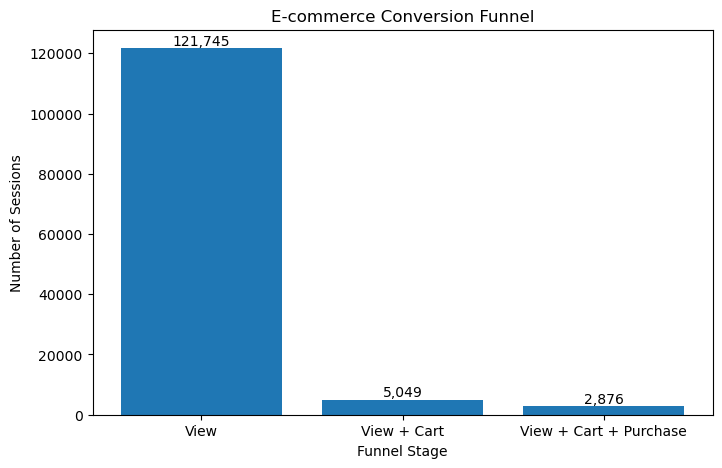

In [42]:
#Funnel Bar Chart
import matplotlib.pyplot as plt

stages = ["View", "View + Cart", "View + Cart + Purchase"]
counts = [121745, 5049, 2876]

plt.figure(figsize=(8,5))
bars = plt.bar(stages, counts)

plt.title("E-commerce Conversion Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha='center',
        va='bottom'
    )

plt.show()

In [43]:
#Top 10 Brands

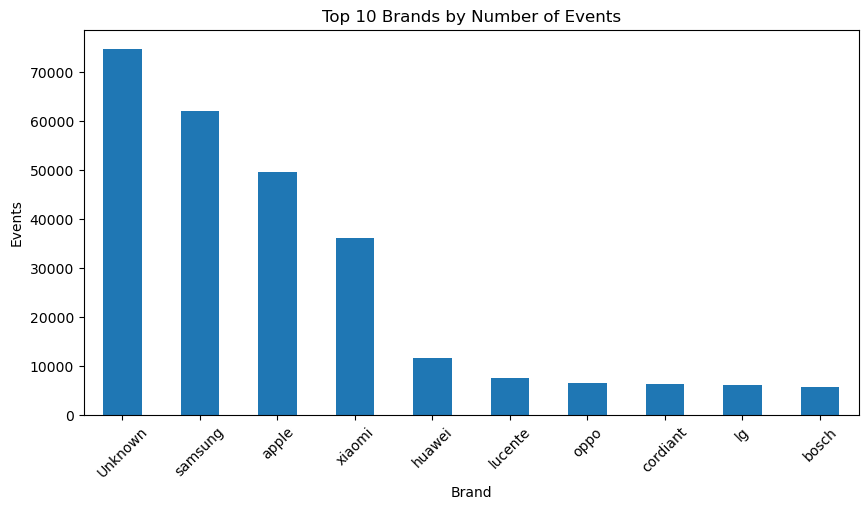

In [44]:
top_brands = df["brand"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_brands.plot(kind="bar")

plt.title("Top 10 Brands by Number of Events")
plt.xlabel("Brand")
plt.ylabel("Events")
plt.xticks(rotation=45)

plt.show()

In [45]:
#Top 10 categories

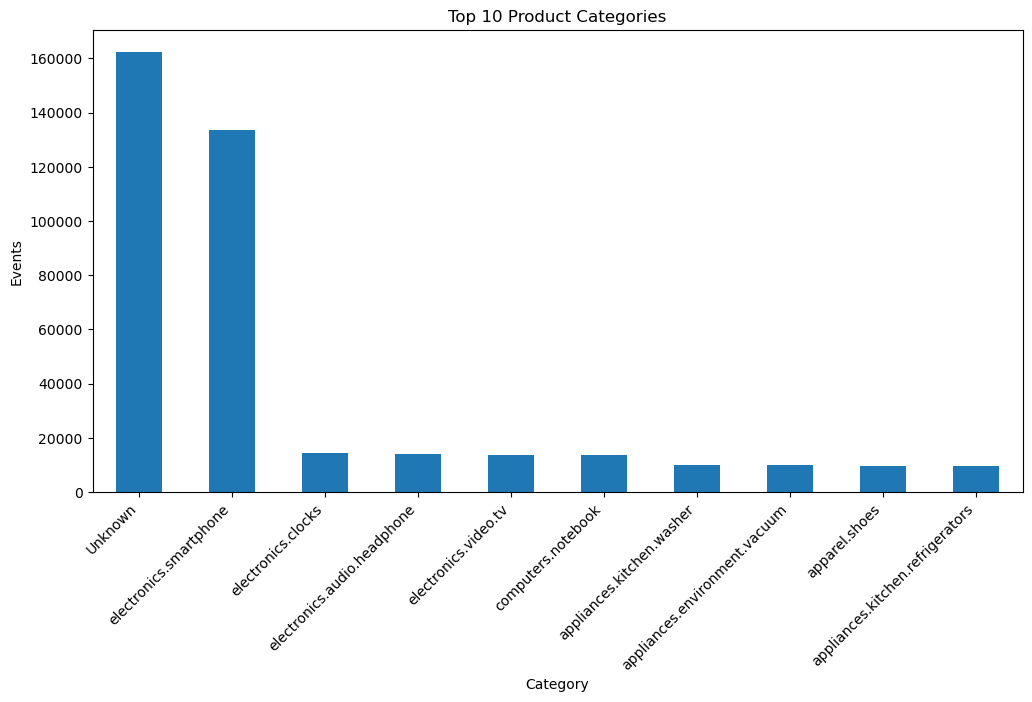

In [46]:
top_categories = df["category_code"].value_counts().head(10)

plt.figure(figsize=(12,6))
top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Events")
plt.xticks(rotation=45, ha="right")

plt.show()


In [47]:
#Event Distribution

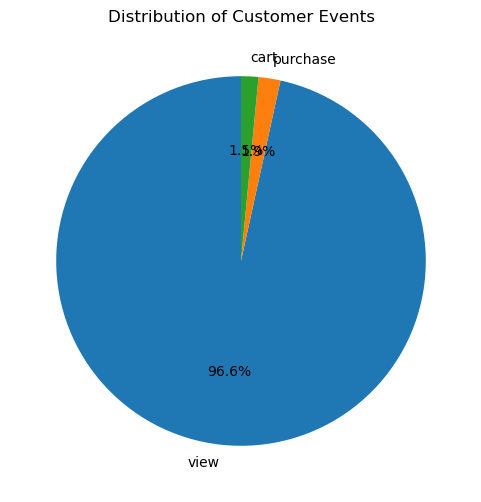

In [48]:
event_counts = df["event_type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    event_counts,
    labels=event_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Customer Events")
plt.show()